Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland

# Exercise03

## Problem

In the last exercise, you used tabular analyses to examine how eviction impacts tenants in Montgomery and Prince George's Counties. In this exercise, you will use more precise, address-level data to analyze evictions across the entire state through a spatial lens.

**You get to write your own research question, but with a few constraints:**
- It should be addressable with the provided eviction data
- It should require that you relate the eviction data to at least one other dataset, which you provide
- It should involve at least one form of spatial analysis (e.g., proximity, overlay, or measurement of another spatial relationship)

**Please write a short abstract (200-300 words) at the top of your exercise notebook that concisely summarizes your research question, how you addressed it, and the results of your analysis. Then provide reproducible code in cells below.**

### Bonus

Only a portion of the eviction records I'm providing for this exercise have addresses that can be geocoded (converting address strings to geographic coordinates) with a high degree of accuracy, or even at all. How could you assess bias in which records are accurately geocoded? (Hint: This will require you to define accuracy.) Can you write a Python script that evaluates whether higher- and lower-accuracy geocodes are randomly distributed across eviction records, or whether certain types of evictions are more or less likely to be geocoded well? **Please report your approach and findings in a separate paragraph and provide supporting code.**

## Data

[Exercise 3 Google Drive Folder](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT)

I'm providing you with eviction warrant data for the whole state of Maryland from 2022 through December 2024. These are from the same District Court of Maryland and Department of Housing and Community Development (DHCD) [source](https://app.powerbigov.us/view?r=eyJrIjoiYWI1Yzg0YjYtNDFkZS00MDUyLThlMDctYmE1ZjY5MGI0MWJhIiwidCI6IjdkM2I4ZDAwLWY5YmUtNDZlNy05NDYwLTRlZjJkOGY3MzE0OSJ9&pageName=ReportSection) as the data from Exercise 2, but also include street addresses. While these data are technically public, it is best practice not to store address-level data on a public GitHub repository. It is also a best practice not to commit large raw data files to Git. For both these reasons, I have shared this dataset in a [Google Drive](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT) folder to which your UMD account has been invited. You should download `md_eviction_warrants_through_2024.csv` store it in the exercise03 directory on your computer before starting to code. 

There is a `.gitignore` file in the exercise03 directory that prevents any `.csv` file from being tracked by Git. As long as you don't modify this `.gitignore`, the raw data file won't get committed, pushed to your remote fork, or included in a pull request back to the course repo.

## File Management and Submitting
To submit, please:
1. Make a new branch on your fork for this exercise.
2. Make a notebook for your exercise with your first name as an underscored suffix (e.g., `exercise02_chester.ipynb`)
    - You can either copy this notebook to work off of or start with a fresh notebook. Your choice.
4. Make commits to that branch as you work on the exercise.
5. Don't commit the eviction warrant CSV or other raw data files to Git.
    - Instead, please add any other raw data files your analysis depends on the [Exercise 3 Google Drive Folder](https://drive.google.com/drive/folders/1QLEnT5B0p43axdNkIvrdnVWpWZgaTeaT).
    - The current `.gitignore` will prevent CSV files from committing. Add additional file names/extensions as necessary.
6. Make a pull request from your branch. Ensure that the only files included in your pull request are those you intended for this exercise.

## Getting Started
To get started, here's some code I developed for geocoding the address in each eviction warrant into a geographic coordinate. You can include all or parts of this code in your own exercise, or just run this notebook to produce the `md_eviction_warrants_through_2024.geoparquet` file and import it into your own notebook to use the results.

### U.S. Census Geocoder
This geocoding process makes use of a [free geocoder provided by the US Census](https://geocoding.geo.census.gov/geocoder/). It's not the most accurate geocoder available, but it's free and fast.

### Breaking Code Into Modules
In this geocoding process, I'm demonstrating an approach to coding where you break code up into multiple modules and then import names between modules. This helps keep things tidy, allows you to easily reuse code that's generalizable between applications (e.g., the `utils.py` module here), and organize code used for more specific purposes (e.g., the `exercise03.py` and `census_geocode.py` modules).

This is exactly how packages work——modules are the basic building blocks. If you wrote an interconnected set of modules to address a certain problem space, you could publish it as a package and let others download it with conda or pip. That's how open-source software gets its start!

In [1]:
import pandas as pd
import geopandas as gpd
import utils
import exercise03
import census_geocode

%load_ext autoreload
%autoreload 2

In [2]:
# Load warrants and make sure zip codes are stored as strings without decimals
warrants_df = pd.read_csv('md_eviction_warrants_through_sept2025.csv')

# Ensure zip codes are stored as strings
warrants_df['TenantZipCode'] = warrants_df['TenantZipCode'].astype('Int64').astype('string')
warrants_df['EventDate'] = pd.to_datetime(warrants_df['EventDate'])
warrants_df['EvictedDate'] = pd.to_datetime(warrants_df['EvictedDate'])
warrants_df['SourceDate'] = pd.to_datetime(warrants_df['SourceDate'])

len(warrants_df) # How many warrants are we working with?

607881

In [3]:
# Rather than geocoding 600K+ addresses, can we get only the unique ones?
geocode_input_df = exercise03.prep_warrants_for_geocoding(warrants_df)

607881 warrants input
Reduced to 205620 unique addresses


In [4]:
# The Census Geocoder API can only accept up to 10K rows at a time, so we have to break
# our dataframe into chunks

# Split into dataframes with less than 10K rows each
geocode_input_dfs = utils.chunk_dataframe(geocode_input_df, 9999)

# Save each dataframe as a CSV without a header
utils.save_dfs_to_csv(geocode_input_dfs, 'geocode_inputs', header=False)

split dataframe into 21 chunks


In [5]:
# Geocode addresses with the Census Geocoder (set test=True to process only one file)
census_geocode.geocode_csvs('geocode_inputs', 'geocode_outputs', test=True)

TEST MODE: Processing only one file.
Saved results to: geocode_outputs\geocoderesult_df_0.csv


In [6]:
# Recombine outputs from geocoder into a single dataframe
geocode_output_df = exercise03.combine_census_geocoded_csvs('geocode_outputs')
len(geocode_output_df)

9999

In [7]:
# Merge geocoded address back onto the inputs with separate fields for address, city, state, and zip
geocoded_df = geocode_input_df.merge(geocode_output_df, left_index=True, right_index=True)
len(geocoded_df)

9999

In [8]:
# Use address, city, state, and zip columns to join geocodes onto original warrant records
warrants_df = warrants_df.merge(geocoded_df, on=['TenantAddress','TenantCity','TenantState','TenantZipCode'])
len(warrants_df)

50754

In [9]:
# Convert warrants into a geodataframe with points
warrants_gdf = utils.lonlat_str_to_geodataframe(warrants_df, 'match_lon_lat')

In [10]:
# What proportion of records have points?
len(warrants_gdf[warrants_gdf.lon.notnull()]) / len(warrants_gdf)

0.9524766520865351

In [11]:
# What proportion of records have exact geocode matches?
len(warrants_gdf[warrants_gdf.match_type == 'Exact']) / len(warrants_gdf)

0.5736690704180951

Parquet is a file format for tabular data that efficiently stores data of many types, including a 'geoparquet' variant that stores geometries like points, lines, and polygons. You can easily save a dataframe or geodataframe to parquet with the `.to_parquet` method. The resulting file will be much smaller and load faster than more convetional formats, such as CSV or shapefile. The downside is that you won't be able to open it with Excel, ArcGIS, or other conventional desktop software.

`pip install pyarrow`

In [12]:
warrants_gdf.to_parquet('md_eviction_warrants_through_sept2025.geoparquet')

You can load a parquet file back to a dataframe with `pd.read_parquet('filename')` or a geoparquet back to a geodataframe with `gpd.read_parquet('filename')`

In [13]:
gdf = gpd.read_parquet('md_eviction_warrants_through_sept2025.geoparquet')

In [14]:
gdf.columns.tolist()

['Unnamed: 0',
 'ID',
 'EventDate',
 'EventType',
 'EventComment',
 'County',
 'Location',
 'TenantAddress',
 'TenantCity',
 'TenantState',
 'TenantZipCode',
 'CaseType',
 'CaseNumber',
 'EvictedDate',
 'Source',
 'SourceDate',
 'Year',
 'EvictionYear',
 'unique_id',
 'input_address',
 'match_status',
 'match_type',
 'match_address',
 'match_lon_lat',
 'match_tiger_line_id',
 'match_tiger_line_side',
 'lon',
 'lat',
 'geometry']

<Axes: >

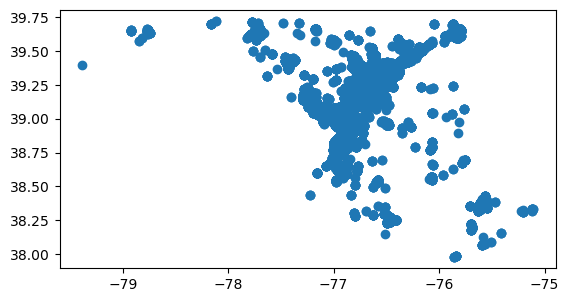

In [15]:
gdf.plot()

In [ ]:
#Research Question: Are eviction warrants more likely to end in actual evictions in Maryland census tracts where there are greater proportions of cost
#burdened renters?

#Abstract: This analysis examines whether eviction petitions in Maryland are more likely to result in actual evictions in Census tracts where
#concentrations of renters aligning with a "cost burdened" status are greater. A "cost burdened" status is defined as renters who spend 30% or more of their
#household income on gross rent. Using the geocoded eviction warrant data from the District Court of Maryland (2022 - 2025), this research assigns the
#identified eviction cases to their respective Census tract using a point to polygon spatial join. Census TIGER 2025 tract boundary data, particularly the 
#shapefile, was used for this spatial analysis. Eviction rates were then calculated for each tract by dividing the number of unique eviction cases to the
#total number of unique cases that began with a petition. American Community Survey (ACS) 5-year Estimates data for renters who are cost burdened 
#(Table B25070) was obtained through a Census API and rates for cost burdened individuals were then calculated. The eviction rates were compared against 
#the percentage of cost burdened renters in each Census tract in two ways: map visualizations and a scatterplot. The results show no clear positive or 
#negative relationship between the eviction rates and rent burdens at the Census tract level. Two things should be noted when considering these results.
#First, the analysis was conducted on a partial dataset as the geocoding of eviction data was done in test mode for one of twenty-one data chunks. Secondly, 
#many of the tracts have a small sample size which can produce unrealiable eviction rates. 

#This exercise utilizes an external data folder/file, for the Census tract boundaries, which is available in the shared Exercise 03 Google Drive, 
# under the name "2025_Maryland_Census_Tracts". Within this folder, the file "tl_2025_24_tract.shp" will be used. 

#Additionally, a personal Census API key will be required to get data from the the ACS. 
#Please obtain one at https://api.census.gov/data/key_signup.html
# When prompted in the code, replace 'YOUR_API_KEY_HERE' with your key

In [16]:
#Import all the important tools and packages for analysis
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
#Load and clean the geocoded eviction data for the goal of the research

#Load the geocoded eviction dataset in the GeoParquet format
evictions = gpd.read_parquet("md_eviction_warrants_through_sept2025.geoparquet")

#Check and drop the rows where no lat/long was found (failed geocoding)
# ~evictions.is_empty will remove empty geometries
# evictions.notna() will remove removes missing geometries
import warnings; warnings.filterwarnings("ignore", "GeoSeries.notna", UserWarning)
evictions = evictions[~evictions.geometry.is_empty & evictions.geometry.notna()]

#Check how many evictions have a valid location (the number of valid records left)
print("Number of eviction warrants with a valid location:", len(evictions))

#Display the data to see what it looks like
evictions.head()

Number of eviction warrants with a valid location: 48342


,Unnamed: 0,ID,EventDate,EventType,EventComment,County,Location,TenantAddress,TenantCity,TenantState,...,input_address,match_status,match_type,match_address,match_lon_lat,match_tiger_line_id,match_tiger_line_side,lon,lat,geometry
0,0,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,8-N GLENSHANON COURT,Baltimore,MD,...,"1910 Fox Street APT 201, Adelphi, MD, 20783",Match,Exact,"1910 FOX ST, ADELPHI, MD, 20783","-76.975276009485,39.00849469185",657096978.0,L,-76.975276009485,39.00849469185,POINT (-76.97528 39.00849)
2,2,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1407-M CLEAR STREAM RD,Baltimore,MD,...,"2825 GRANTLEY AVE, BALTIMORE, MD, 21215",Match,Exact,"2825 GRANTLEY AVE, BALTIMORE, MD, 21215","-76.667147580336,39.337399996263",206406302.0,L,-76.667147580336,39.337399996263,POINT (-76.66715 39.3374)
3,3,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1208-M WINDSAIL ROAD,Baltimore,MD,...,"2008 KINTORE CIRCLE #103, ODENTON, MD, 21113",Match,Exact,"2008 KINTORE CIR, ODENTON, MD, 21113","-76.7136333616,39.099213391212",636754538.0,R,-76.7136333616,39.099213391212,POINT (-76.71363 39.09921)
4,4,NaN,2025-09-30,Warrant of Restitution - Return of Service - E...,NaN,Prince George's,Hyattsville,4105 51st Street APT 202,Bladensburg,MD,...,"1035-G MISTY LYNN CIRCLE, Cockeysville, MD, 21030",Match,Non_Exact,"1035 MISTY LYNN CIR, COCKEYSVILLE, MD, 21030","-76.61524292553,39.464536287223",650540325.0,R,-76.61524292553,39.464536287223,POINT (-76.61524 39.46454)
5,5,NaN,2025-09-30,Warrant of Restitution - Return of Service - C...,NaN,Baltimore,Essex,1200-C WINDSAIL ROAD,Baltimore,MD,...,"3-D RAMBLING OAKS WAY, Catonsville, MD, 21228",Match,Non_Exact,"3 RAMBLING OAKS WAY, CATONSVILLE, MD, 21228","-76.724391225519,39.287891513437",191556990.0,L,-76.724391225519,39.287891513437,POINT (-76.72439 39.28789)


In [19]:
#Main Objective: Load the Maryland Census tract boundaries so evictions can be assigned to tracts 

#Load tract boundaries
tracts = gpd.read_file("2025_Maryland_Census_Tracts/tl_2025_24_tract.shp")

#Match coordinate systems with the eviction data 
tracts = tracts.to_crs("EPSG:4326")

#Display how many Census tracts there are see what the data looks like
print("Number of Census tracts in Maryland:", len(tracts))
tracts.head()

Number of Census tracts in Maryland: 1475


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,24,013,511000,24013511000,1400000US24013511000,5110,Census Tract 5110,G5020,S,62927091,250389,+39.5362529,-077.0856235,"POLYGON ((-77.15966 39.53446, -77.15943 39.534..."
1,24,510,160600,24510160600,1400000US24510160600,1606,Census Tract 1606,G5020,S,556403,0,+39.2967497,-076.6640074,"POLYGON ((-76.66968 39.29445, -76.66961 39.294..."
2,24,510,271802,24510271802,1400000US24510271802,2718.02,Census Tract 2718.02,G5020,S,530270,0,+39.3446843,-076.6770690,"POLYGON ((-76.68345 39.34311, -76.68326 39.343..."
3,24,005,411309,24005411309,1400000US24005411309,4113.09,Census Tract 4113.09,G5020,S,9048188,5156,+39.4106874,-076.4405230,"POLYGON ((-76.46417 39.40002, -76.46411 39.400..."
4,24,005,408303,24005408303,1400000US24005408303,4083.03,Census Tract 4083.03,G5020,S,14620173,37743,+39.4688739,-076.7121070,"POLYGON ((-76.74015 39.49531, -76.74014 39.495..."


In [20]:
#Main Objective: Conduct a spatial join so that each eviction point is assigned to the census tract that it falls inside of, given the latitude and longitude

#Match each eviction point to a Census tract
evictions_joined = gpd.sjoin(
    evictions,
    tracts[["GEOID", "geometry"]],
    how = "left", 
    predicate = "within"  #This will find the which eviction points fall into each tract polygon
)

#Check how many of the evictions were able to be matched with a tract
print("Total number of eviction warrants:", len(evictions_joined))
print("Number of evictions matched to a tract:", evictions_joined["GEOID"].notna().sum())
print("Number of evictions not matched:", evictions_joined["GEOID"].isna().sum())

Total number of eviction warrants: 48342
Number of evictions matched to a tract: 48342
Number of evictions not matched: 0


In [21]:
#Main Object: Create a function that calculates the eviction rate by a certain geography. Cases should be counted once to see which ones actually
#end in an eviction. 

def eviction_rate_by_geography(df, geography_column):
    """Calculate the eviction rates by geographic units

    df: GeoDataFrame of the eviction warrants after the spatial join
    geography_column: Column that will be used to group the data by (e.g., "GEOID" for census tracts)

    """

    #Create a copy of the dataframe so the original stays as is
    df = df.copy()

    #Identity the petitions and the eviction events
    #Standardizing the text in the "EventType" makes it easier to identify the all petitions in case there are inconsistencies in the way the data was inputed
    df["is_petition"] = df["EventType"].str.lower().str.strip() == "petition - for warrant of restitution filed"

    #Standardizing the text in the "EventType" makes it easier to identify which petitions actually ended in evictions, in case there are inconsistencies
    #in the way the data was inputed
    df["is_evicted"] = df["EventType"].str.lower().str.strip() == "warrant of restitution - return of service - evicted"

    #Group by the case number and geography to get one row per unqiue case
    case_level = df.groupby(["CaseNumber", geography_column]).agg({
        "is_petition" : "max", 
        "is_evicted" : "max"
    }).reset_index()

    #Keep only the cases that started with a petition
    case_level = case_level[case_level["is_petition"] == True]

    #Count the total number of cases or filed petitions and the number of evicted cases per georgaphy
    summary = case_level.groupby(geography_column).agg(
        total_cases = ("is_petition", "count"), 
        evicted_cases = ("is_evicted", "sum")
    ).reset_index()

    #Calcuate the eviction rate as a percentage over the number of cases that started the eviction process
    summary["eviction_rate"] = (summary["evicted_cases"] / summary["total_cases"] * 100)

    return summary




In [22]:
#Main Objective: Use the defined function to calculate the eviction rate by Census tract

tract_summary = eviction_rate_by_geography(evictions_joined, "GEOID")

tract_summary.head()

,GEOID,total_cases,evicted_cases,eviction_rate
0,24001000500,1,0,0.0
1,24001000600,10,1,10.0
2,24001000700,1,0,0.0
3,24001000800,7,0,0.0
4,24001001000,5,0,0.0


In [24]:
#Main Objective: Create a function to maake a request for ACS data using an API for renter cost burden data on the Census tract level

def get_cost_burden_data(api_key):
    """"Seek the renter cost burden data for all Census tracts in Maryland from the Census ACS 5-year estimates API

    api_key: your personal Census API key

    """

    #The Census API request URL
    url = "https://api.census.gov/data/2024/acs/acs5"


    #Define the parameteres of the ACS 5-year estimates request
    #Look for data under the Census code B25070: Gross Rent as a Percentage of Household Income in the Past 12 Months
    #B25070_001E is the total number of renter households
    #B25070_007E - 010E are the number of renters that are "cost burdened" or paying 30% of their income on rent
    data_parameters = {
        "get": "NAME,B25070_001E,B25070_007E,B25070_008E,B25070_009E,B25070_010E",  
        "for": "tract:*",   #Get data for every Census tract
        "in": "state:24",   #Filter the request to only the state of Maryland (FIPS code 24)
        "key": api_key
    }

    #Make the GET request to the Census API and obtain the JSON content
    response = requests.get(url, params = data_parameters)
    data = response.json()

    #Turn the JSON into a DataFrame
    acs = pd.DataFrame(data[1:], columns = data[0])

    #Convert the columns of data from strings to numbers
    columns = ["B25070_001E","B25070_007E","B25070_008E","B25070_009E","B25070_010E"]
    for col in columns:
        acs[col] = pd.to_numeric(acs[col], errors = "coerce")      #The coerce will replace any values that can't be converted to a "NaN" value 

    #State, county, and tract columns will need to be combined to create the GEOID. This will then be used to match the rows across the datasets used
    acs["GEOID"] = acs["state"] + acs["county"] + acs["tract"]

    #The renter cost burdened "brackets" (30% and greater) should be added to find the total number of cost burdened renters
    acs["cost_burdened"] = (acs["B25070_007E"] + acs["B25070_008E"] + acs["B25070_009E"] + acs["B25070_010E"])

    #Calculate the percent of renters who are cost burdened by dividing the renters from the total number of renter households
    acs["percent_cost_burdened"] = (acs["cost_burdened"] / acs["B25070_001E"]) * 100
    
    #Return the columns we need
    return acs[["GEOID", "percent_cost_burdened"]]

In [ ]:
#Main Objective: Retrieve and load the cost burden data
#Replace the "YOUR_API_KEY_HERE" with your personal Census API key
#Get your API key (if you need it): https://api.census.gov/data/key_signup.html

API_KEY = "YOUR_API_KEY_HERE"

acs_data = get_cost_burden_data(API_KEY)

acs_data.head()

,GEOID,percent_cost_burdened
0,24001000100,20.462046
1,24001000200,29.323308
2,24001000500,62.006079
3,24001000600,31.318681
4,24001000700,51.181102


In [29]:
#Main Objective: Merge the spatial data for the tracts, eviction rates, and the cost burden data together with the GEOID column

#Join the eviction rates to the tracts using the shared GEOID column
tracts_merged = tracts.merge(tract_summary, 
                             on = "GEOID", 
                             how = "left")

#Join the renter cost burden data with the merged table above using the shared GEOID column
tracts_merged = tracts_merged.merge(acs_data, 
                                    on = "GEOID", 
                                    how = "left")

#Replace any missing eviction values with 0, so that tracts with missing values will show 0
#After the merge, tracts with no observed filings were assigned a NaN value, so they can reasonably be assigned a 0 value
tracts_merged["eviction_rate"] = tracts_merged["eviction_rate"].fillna(0)   #There is a 0% eviction rate in this tract
tracts_merged["evicted_cases"] = tracts_merged["evicted_cases"].fillna(0)   #There are 0 cases that ended up in evictions in this tract
tracts_merged["total_cases"] = tracts_merged["total_cases"].fillna(0)       #There are 0 petitions in this tract

#Check for what the missing values look like
print("Tracts missing cost burden data:", tracts_merged["percent_cost_burdened"].isna().sum())
print("Tracts with 0 petitions filed:", (tracts_merged["total_cases"] == 0).sum())
print("Tracts with 0 cases ending in eviction:", (tracts_merged["evicted_cases"] == 0).sum())

#Display the columns we want to see 
tracts_merged[["GEOID", "evicted_cases","total_cases", "eviction_rate", "percent_cost_burdened"]].head()

Tracts missing cost burden data: 22
Tracts with 0 petitions filed: 589
Tracts with 0 cases ending in eviction: 1019


,GEOID,evicted_cases,total_cases,eviction_rate,percent_cost_burdened
0,24013511000,0.0,0.0,0.000000,33.898305
1,24510160600,2.0,36.0,5.555556,58.271865
2,24510271802,1.0,41.0,2.439024,69.074492
3,24005411309,1.0,8.0,12.500000,39.591837
4,24005408303,0.0,0.0,0.000000,NaN


In [30]:
#Main Objective: Filter the merged data for the analysis

#For the maps: NaN data in the percent of cost burdened renters for each tract could be the sign of missing values, so we can't replace those with a 0 value,
#but the maps should display with cost burdened data for comparison
tracts_map = tracts_merged[tracts_merged['percent_cost_burdened'].notna()].copy()
print("Census tracts shown on the map:", len(tracts_map))

#For the scatterplot: work on keeping Census tracts with at least one filed petition and valid cost burden data (no NaN). Tracts with no petition 
#can't give us any meaningful eviction rates so they can be excluded in the scatterplot analysis
tracts_scatter = tracts_merged[(tracts_merged["total_cases"] > 0) & (tracts_merged["percent_cost_burdened"].notna())].copy()
print("Census tracts used in scatterplot:", len(tracts_scatter))



Census tracts shown on the map: 1453
Census tracts used in scatterplot: 886


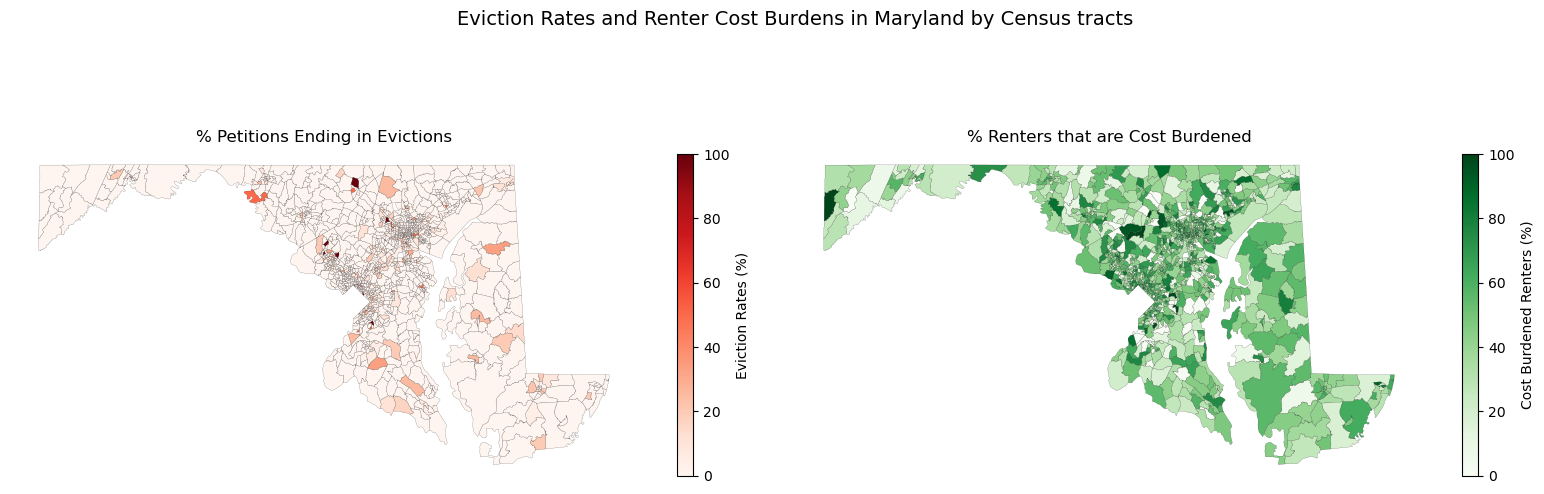

In [ ]:
#Main Objective: Create side-by-side maps to show eviction rates and the percent of cost burdened renters in each Census tract in Maryland

def eviction_burden_maps(gdf):
    """"Plot comparison maps of the eviction rate and percent of cost burdened renteres in Maryland Census tracts

    gdf: GeoDataFrame with the eviction_rate and percent_cost_burdened columns for the maps

    """

    #Create a figure with two map panels
    fig, axes = plt.subplots(1, 2, figsize = (16, 6))

    #Left map: Display the eviction rate by Census tract. Each tract will visually show the percentage of petitions that actually ended in an eviction
    gdf.plot(
        column = "eviction_rate", 
        cmap = "Reds", 
        legend = True, 
        legend_kwds = {"label" : "Eviction Rates (%)", "shrink" : 0.6}, 
        linewidth = 0.1, 
        edgecolor = "black",
        ax = axes[0]
    )

    axes[0].set_title("% Petitions Ending in Evictions")
    axes[0].axis("off")

    #Right map: Display the percent of people who are under the "cost burdened" status by Census tract. Each tract will visually show the percentage of
    #renters that pay more than 30% of their income towards their rent
    gdf.plot(
        column = "percent_cost_burdened", 
        cmap = "Greens", 
        legend = True, 
        legend_kwds = {"label" : "Cost Burdened Renters (%)", "shrink" : 0.6}, 
        linewidth = 0.1, 
        edgecolor = "black",
        ax = axes[1], 
    )

    axes[1].set_title("% Renters that are Cost Burdened")
    axes[1].axis("off")

    
    plt.suptitle("Eviction Rates and Renter Cost Burdens in Maryland by Census tracts", fontsize = 14)
    plt.tight_layout()
    plt.show()

#Display the created maps
eviction_burden_maps(tracts_map)

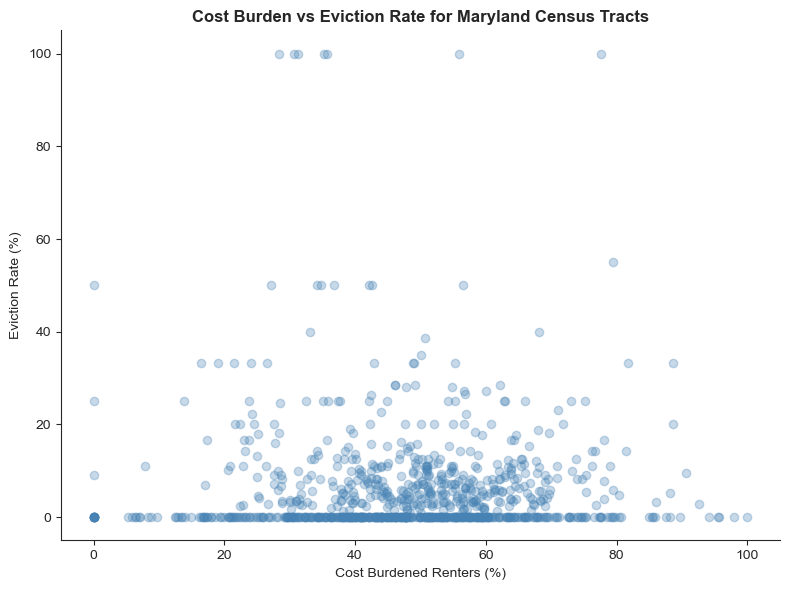

In [32]:
#Main Objective: Create a scatterplot to examine the relationship between the eviction rate and percent of people who are cost burdened 
#Only tracts with at least one filed petition are included, otherwise eviction rates would not be able to be calculated

#A similar style to Demo 7 was followed here
sns.set_style("ticks")

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111)

ax.scatter(
    tracts_scatter["percent_cost_burdened"], 
    tracts_scatter["eviction_rate"], 
    alpha = 0.3, 
    color = "steelblue"
)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

font = {"fontname" : "Arial"}
title_font = {**font, **{"fontweight" : "bold"}}

plt.xlabel("Cost Burdened Renters (%)", **font)
plt.ylabel("Eviction Rate (%)", **font)
plt.title("Cost Burden vs Eviction Rate for Maryland Census Tracts", **title_font)

plt.tight_layout()
plt.show()